In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay


#load the data
data = pd.read_csv("glass.data", header=None)
columns = ['ID', 'RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'type']

data.columns = columns


#get featuresa and labels
X = data.drop(["type", "ID"], axis = 1)
y = data["type"]
#scale the features
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X = pd.DataFrame(X)

print(X.shape)
print(y.shape)

#train and test
studentID = 39358631
np.random.seed(studentID)
indecies= np.random.permutation(len(X))


#split
splitNum = int(0.8 *len(X))
trainIndex = indecies[:splitNum]
testIndex = indecies[splitNum:]

X_train = X.iloc[trainIndex].values
X_test = X.iloc[testIndex].values
y_train = y.iloc[trainIndex].values
y_test = y.iloc[testIndex].values

print("trainingf: ", X_train.shape)
print("testing: ", X_test.shape)


def accuracy(y_true, y_guessed):
    corect = 0

    for i in range(len(y_true)):
        if y_true[i] == y_guessed[i]:
            corect += 1
    
    return corect /len(y_true)

#labels for cm
label_names = {
    1: "building_float",
    2: "building_non_float",
    3: "vehicle",
    5: "containers",
    6: "tableware",
    7: "headlamps"
    }

labels = np.unique(y_test)
display_labels = [label_names[l] for l in labels]


(214, 9)
(214,)
trainingf:  (171, 9)
testing:  (43, 9)


best k =  6 best accuracy =  0.6046511627906976


testing time: 0.0005171298980712891
accuracy: 0.6046511627906976
matrix:
 [[8 0 0 0 0 0]
 [6 7 0 0 0 0]
 [4 1 1 0 0 0]
 [0 0 0 1 1 1]
 [0 1 0 1 0 1]
 [1 0 0 0 0 9]]


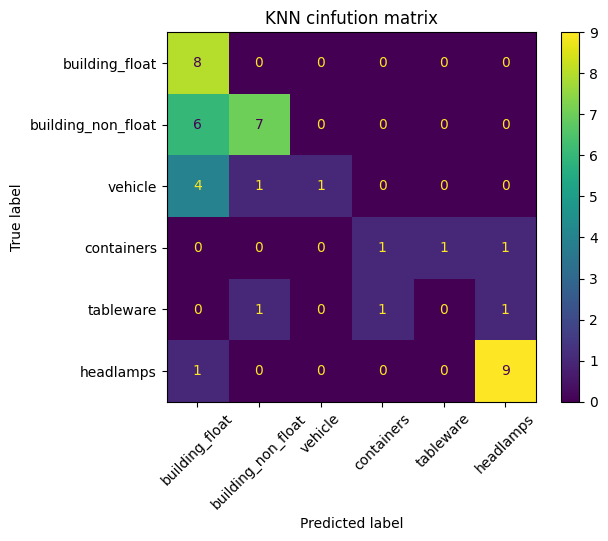

In [5]:
#KNN

#train    
def fit(X, y):
    model = {}
    model["X_train"] = X
    model["y_train"] = y
    return model

#guess
def guess(model, X, k):
    X_train = model["X_train"]
    y_train = model["y_train"]
    
    guesses = []
    for x in X:
        distance = np.sum((X_train - x)**2,axis=1 )
        k_indicies = np.argsort(distance)[:k]
        k_classes = y_train[k_indicies]
        mostCommon = np.bincount(k_classes).argmax()
        guesses.append(mostCommon)
    return np.array(guesses)



#storing
model = fit(X_train, y_train)


#find best k
best_k = 1
best_acc = 0
#guessing time test
for k in range(1,50):
    y_guess = guess(model ,X_test, k)
    #accuracy
    acc = accuracy(y_test, y_guess)

    if acc > best_acc:
        best_acc = acc
        best_k = k
print("best k = ", best_k, "best accuracy = ", best_acc)

start_time  = time.time()
y_guess = guess(model ,X_test, best_k)
test_time = time.time() - start_time

accuracy
acc = accuracy(y_test, y_guess)

#confution matrix
matrix = confusion_matrix(y_test, y_guess)

print("\n")
print("testing time:", test_time)
print("accuracy:", acc)
print("matrix:\n", matrix)



display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=display_labels)
display.plot(xticks_rotation=45)
plt.title("KNN cinfution matrix")
plt.show()

    


training time : 0.20092105865478516
testing time: 6.508827209472656e-05
accuracy: 0.7674418604651163
matrix:
 [[8 0 0 0 0 0]
 [2 8 3 0 0 0]
 [2 0 4 0 0 0]
 [0 0 0 3 0 0]
 [0 0 0 0 2 1]
 [1 1 0 0 0 8]]


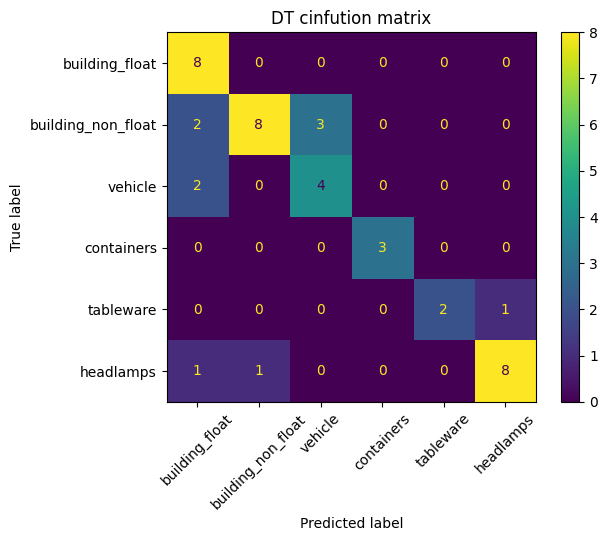

In [4]:
#DT
class Node:
    def __init__(self, feature = None, threshold = None, left = None, right = None, value = None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value


#entropy 
def entropy(y):
    labels = np.unique(y)
    entropy_value = 0

    #get probability and find entropy
    for i in labels:
        probability = np.sum(y==i)/ len(y)
        entropy_value -= probability * np.log2(probability)
    return entropy_value

#information gain
def information_gain(y, left_y, right_y):
    paren_entropy = entropy(y)

    n = len(y)
    n_left = len(left_y)
    n_right = len(right_y)

    #weighted 
    child_entropy = (n_left/n) * entropy(left_y) + (n_right/n) * entropy(right_y)

    #information gain 
    gain = paren_entropy - child_entropy
    return gain


def split(X, y):
    best_gain = -1
    best_threshold = None
    best_feature = None

    num_features = X.shape[1]

    for feature in range (num_features):
        #get the values for split
        values = np.unique(X[:,feature])

        #split
        for threshold in values:
            left_node = X[:, feature] <= threshold
            right_node = X[:, feature] > threshold
            if np.sum(left_node) == 0 or np.sum(right_node) == 0:
                continue
                 
            left_y = y[left_node]
            right_y = y[right_node]

            #get the information gain
            gain = information_gain(y, left_y, right_y)

            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_threshold = threshold
    
    return best_feature, best_threshold       

#recursive tree build
def buidTree(X, y, depth=0, max_depth = 10):
    if len(np.unique(y)) == 1:
        return Node(value=y[0])

    if depth >= max_depth:
        leaf = np.bincount(y).argmax()
        return Node(value=leaf)

    feature, threshold = split(X, y)

    if feature is None:
        leaf = np.bincount(y).argmax()
        return Node(value=leaf)
    
    left_node = X[:, feature] <= threshold
    right_node = X[:, feature] > threshold

    left = buidTree(X[left_node], y[left_node], depth +1, max_depth)
    right = buidTree(X[right_node], y[right_node], depth +1, max_depth)

    return Node(feature, threshold, left, right)

def predict_tree(x, node):
    if node.value is not None:
        return node.value
    
    if x[node.feature] <= node.threshold:
        return predict_tree(x, node.left)
    else:
        return predict_tree(x, node.right)
    
#predict all the samples 
def predict(X, tree):
    predictions = []

    for x in X:
        predictions.append(predict_tree(x, tree))
    return np.array(predictions)


#training time test
start_time_train_tree  = time.time()
tree = buidTree(X_train, y_train)
train_time_tree = time.time() - start_time_train_tree

#predict time test
start_time_predict_tree  = time.time()
y_predict = predict(X_test, tree)
test_time_tree = time.time() - start_time_predict_tree

#acuracy
acc = accuracy(y_test, y_predict)

#matrix
matrix = confusion_matrix(y_test, y_predict)


print("training time :", train_time_tree)
print("testing time:", test_time_tree)
print("accuracy:", acc)
print("matrix:\n", matrix)

display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=display_labels)
display.plot(xticks_rotation=45)
plt.title("DT cinfution matrix")
plt.show()




training time : 0.0007202625274658203
testing time: 0.0018970966339111328
accuracy: 0.4186046511627907
matrix:
 [[4 0 4 0 0 0]
 [8 1 3 1 0 0]
 [3 0 2 0 1 0]
 [0 1 0 1 0 1]
 [0 0 0 0 1 2]
 [1 0 0 0 0 9]]


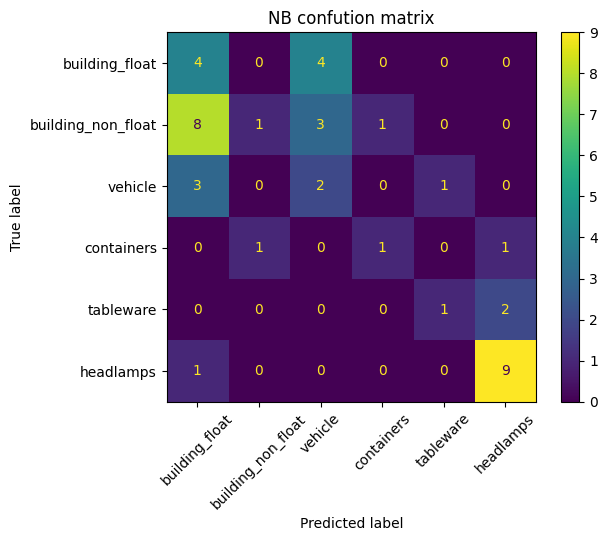

In [6]:
#naive baysed

class Naive:
    def __init__(self):
        self.classes = None
        self.mean = None
        self.var = None
        self.probability = None

    #trai 
    def fit(self, X, y):
        #the classes
        num_samples, num_features = X.shape
        self.classes = np.unique(y)
        num_classes = len(self.classes)
        

        self.mean = np.zeros((num_classes, num_features))
        self.var = np.zeros((num_classes, num_features))
        self.probability = np.zeros(num_classes)

        #get the stats for all classes
        for index, c in enumerate(self.classes):
            X_c = X[y == c]

            #get mean and varience
            self.mean[index, :] = X_c.mean(axis = 0) 
            self.var[index, :] = X_c.var(axis = 0) + 1e-9
            #get probability 
            self.probability[index] = X_c.shape[0] / float(num_samples)
    
    #get  final prediction with gaussian 
    def gaussian(self, class_index, x):
        #get mean and var
        mean = self.mean[class_index]
        var = self.var[class_index] 

        #numerator and denominator
        numerator = np.exp(-(x - mean)**2 / (2*var))
        denominator = np.sqrt(2 * np.pi * var)
        probability = numerator / denominator

        return probability
    
    #predict for one sample 
    def predict_one_naive(self, x):
        posteriors = []

        #loop through the classes and get the probability
        for index, c in enumerate(self.classes):
            probability = np.log(self.probability[index])

            chance = np.sum(np.log(np.maximum(self.gaussian(index, x), 1e-100)) )
            posterior = probability + chance

            posteriors.append(posterior)

        return self.classes[np.argmax(posteriors)]
    
    #predict all samples
    def predict_all(self, X):
        y_predict = []

        for x in X:
            y_predict.append(self.predict_one_naive(x))
        
        return np.array(y_predict)
    
naive = Naive()

#training time test
start_time_train_naive  = time.time()
naive.fit(X_train, y_train)
train_time_naive = time.time() - start_time_train_naive

#predict time test
start_time_predict_naive  = time.time()
y_predict = naive.predict_all(X_test)
test_time_naive = time.time() - start_time_predict_naive

#acuracy
acc = accuracy(y_test, y_predict)

#matrix
matrix = confusion_matrix(y_test, y_predict)


print("training time :", train_time_naive)
print("testing time:", test_time_naive)
print("accuracy:", acc)
print("matrix:\n", matrix)

display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=display_labels)
display.plot(xticks_rotation=45)
plt.title("NB confution matrix")
plt.show()

    
